# **04 — VISUALISASI & DASHBOARD ANALITIK**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
from collections import Counter
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("clustered_dataset.csv")
print(f"Data dimuat: {df.shape}")

Data dimuat: (1465, 28)


In [3]:
COLORS = ['#2980b9', '#e74c3c', '#27ae60', '#f39c12', '#8e44ad', '#16a085']

## 1. Distribusi Platform

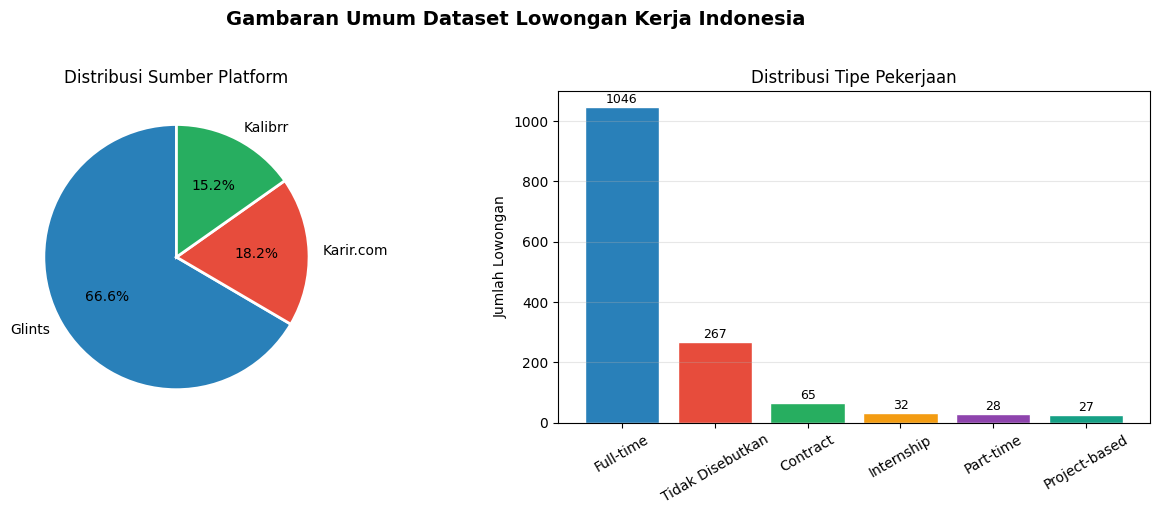

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gambaran Umum Dataset Lowongan Kerja Indonesia",
             fontsize=14, fontweight='bold', y=1.02)

# Pie chart: platform
platform_counts = df['source_platform'].value_counts()
axes[0].pie(platform_counts.values,
            labels=platform_counts.index,
            colors=COLORS[:len(platform_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title("Distribusi Sumber Platform")

# Bar chart: job type
jt_counts = df['job_type_clean'].value_counts()
bars = axes[1].bar(jt_counts.index, jt_counts.values,
                   color=COLORS[:len(jt_counts)], edgecolor='white')
axes[1].set_title("Distribusi Tipe Pekerjaan")
axes[1].set_ylabel("Jumlah Lowongan")
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, jt_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Top Lokasi

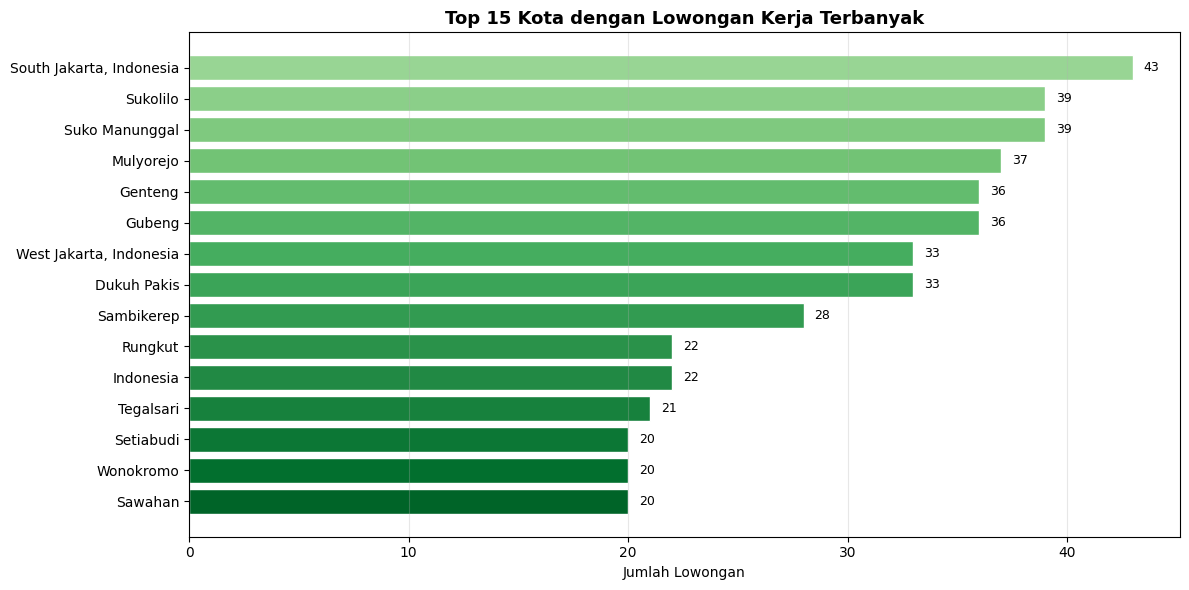

In [5]:

top_locations = df[df['location'] != 'Tidak Diketahui']['location'].value_counts().head(15)
colors_loc = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_locations)))[::-1]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_locations.index[::-1], top_locations.values[::-1],
               color=colors_loc, edgecolor='white')
ax.set_title("Top 15 Kota dengan Lowongan Kerja Terbanyak",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Jumlah Lowongan")
for bar, val in zip(bars, top_locations.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Distribusi Pendidikan

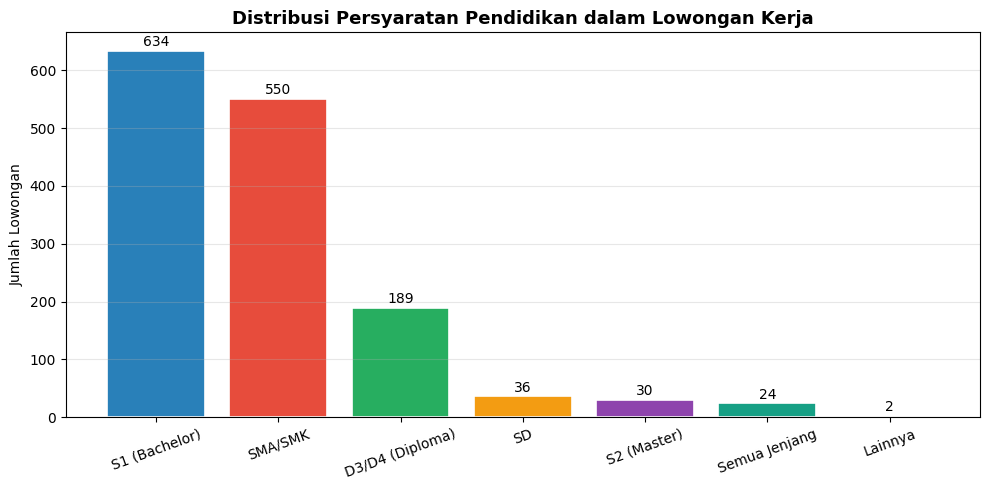

In [6]:
edu_counts = df['education_clean'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(edu_counts.index, edu_counts.values,
              color=COLORS[:len(edu_counts)], edgecolor='white', linewidth=1.2)
ax.set_title("Distribusi Persyaratan Pendidikan dalam Lowongan Kerja",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Jumlah Lowongan")
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, edu_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Tren Posting Bulanan

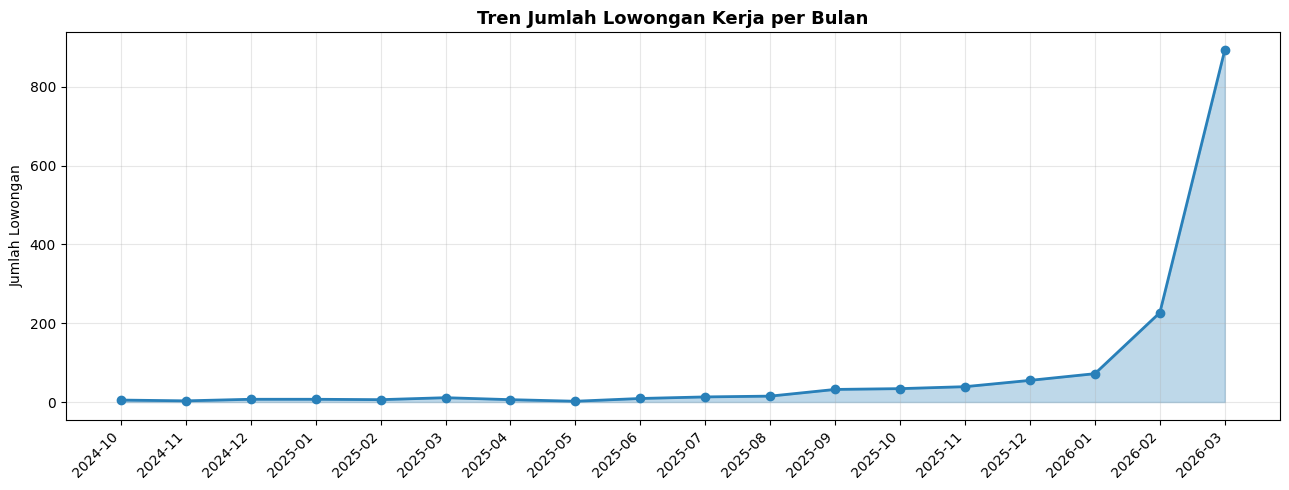

In [7]:
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')
monthly = df.groupby(df['posted_date'].dt.to_period('M')).size()
monthly = monthly[monthly.index.notna()].sort_index().tail(18)  # 18 bulan terakhir

if len(monthly) > 2:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.fill_between(range(len(monthly)), monthly.values, alpha=0.3, color='#2980b9')
    ax.plot(range(len(monthly)), monthly.values, 'o-', color='#2980b9',
            linewidth=2, markersize=6)
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha='right')
    ax.set_title("Tren Jumlah Lowongan Kerja per Bulan",
                 fontsize=13, fontweight='bold')
    ax.set_ylabel("Jumlah Lowongan")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Distribusi Gaji

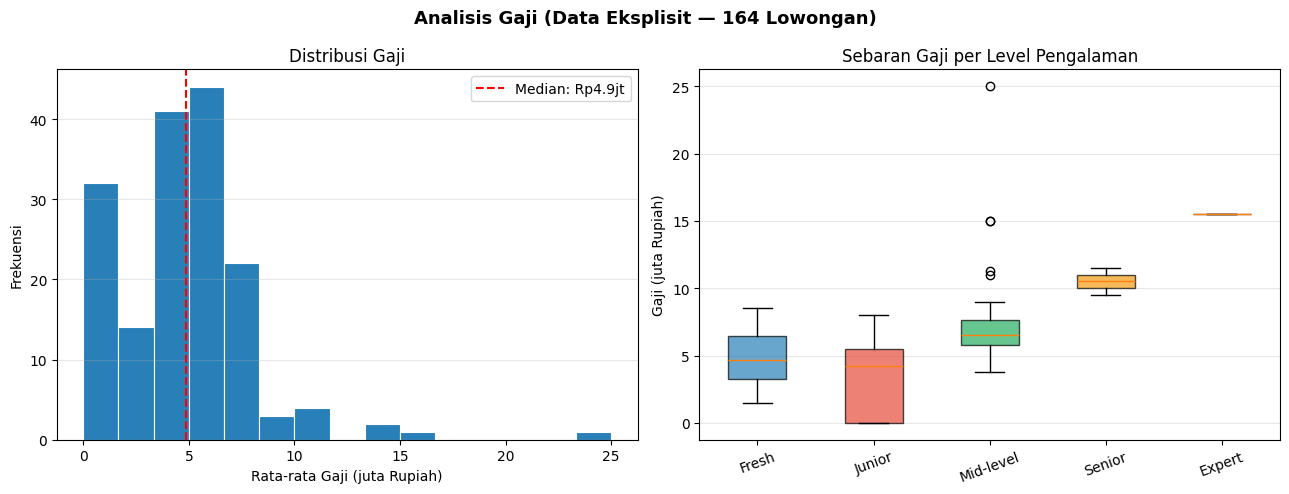

In [8]:
df_salary = df[df['salary_avg'].notna()].copy()
if len(df_salary) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Analisis Gaji (Data Eksplisit — 164 Lowongan)",
                 fontsize=13, fontweight='bold')

    # Histogram gaji
    axes[0].hist(df_salary['salary_avg'] / 1e6, bins=15,
                 color='#2980b9', edgecolor='white', linewidth=0.8)
    axes[0].set_xlabel("Rata-rata Gaji (juta Rupiah)")
    axes[0].set_ylabel("Frekuensi")
    axes[0].set_title("Distribusi Gaji")
    axes[0].axvline(df_salary['salary_avg'].median() / 1e6, color='red',
                    linestyle='--', label=f"Median: Rp{df_salary['salary_avg'].median()/1e6:.1f}jt")
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Boxplot gaji per exp category
    exp_order = ['Fresh Graduate', 'Junior (≤1 tahun)', 'Mid-level (2-3 tahun)',
                 'Senior (4-5 tahun)', 'Expert (>5 tahun)']
    valid_exp = [e for e in exp_order if e in df_salary['exp_category'].values]
    data_by_exp = [df_salary[df_salary['exp_category'] == e]['salary_avg'].values / 1e6
                   for e in valid_exp]

    bp = axes[1].boxplot(data_by_exp, labels=[e.split(' ')[0] for e in valid_exp],
                         patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_ylabel("Gaji (juta Rupiah)")
    axes[1].set_title("Sebaran Gaji per Level Pengalaman")
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


## 6. Dashboard Ringkasan

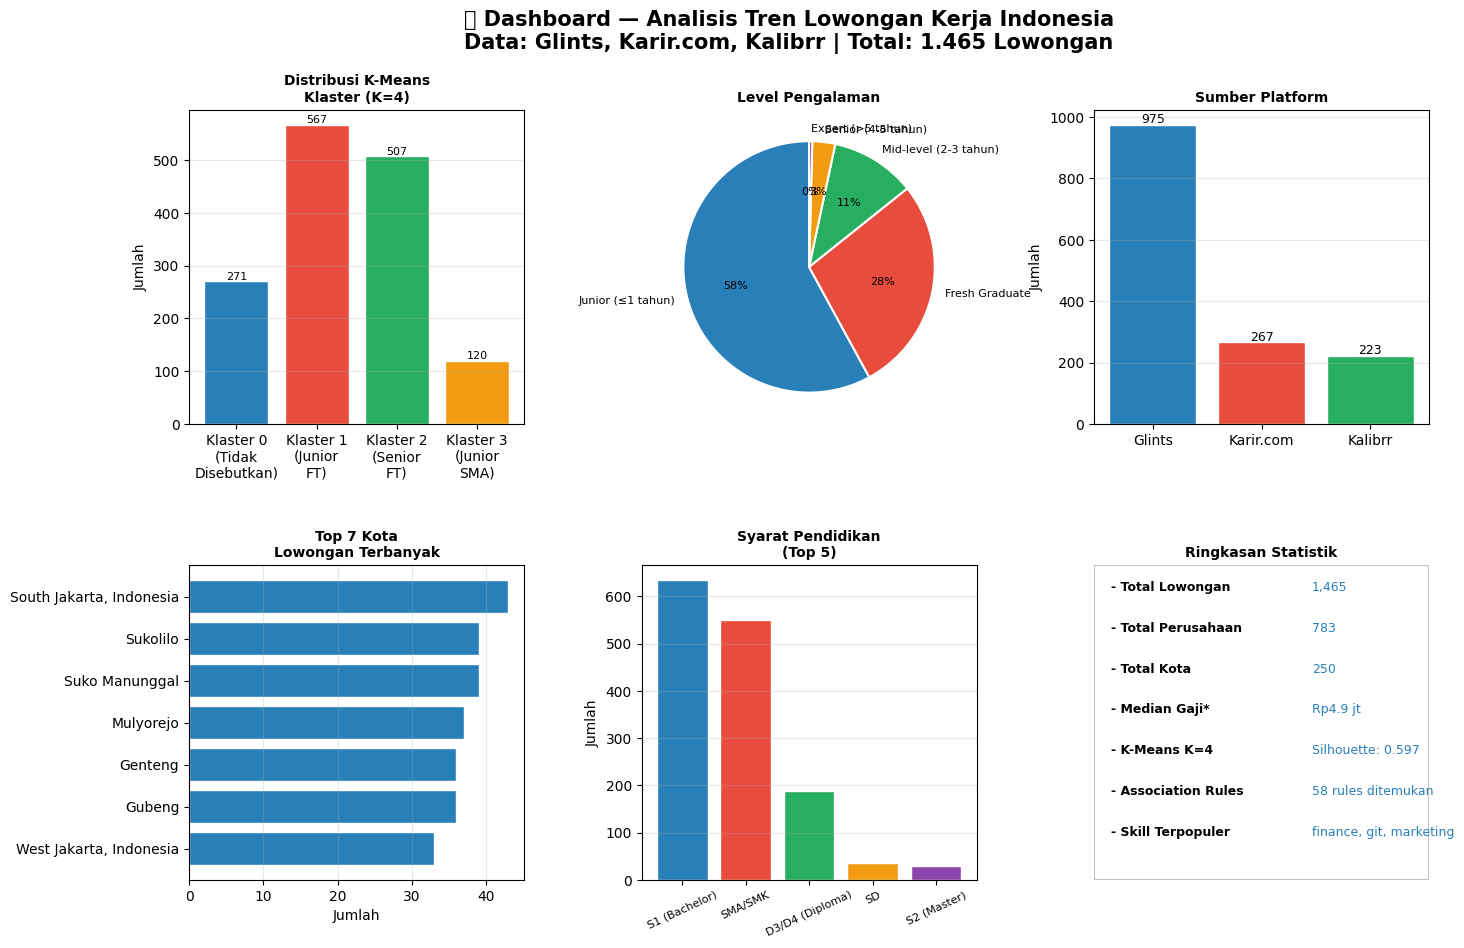


=== SEMUA VISUALISASI SELESAI ===


In [9]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("📊 Dashboard — Analisis Tren Lowongan Kerja Indonesia\nData: Glints, Karir.com, Kalibrr | Total: 1.465 Lowongan",
             fontsize=15, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1: Klaster
ax1 = fig.add_subplot(gs[0, 0])
cluster_counts = df['cluster'].value_counts().sort_index()
cluster_labels_short = ['Klaster 0\n(Tidak\nDisebutkan)', 'Klaster 1\n(Junior\nFT)',
                         'Klaster 2\n(Senior\nFT)', 'Klaster 3\n(Junior\nSMA)']
ax1.bar(cluster_labels_short, cluster_counts.values, color=COLORS[:4], edgecolor='white')
ax1.set_title("Distribusi K-Means\nKlaster (K=4)", fontsize=10, fontweight='bold')
ax1.set_ylabel("Jumlah")
ax1.grid(axis='y', alpha=0.3)
for i, val in enumerate(cluster_counts.values):
    ax1.text(i, val + 3, str(val), ha='center', fontsize=8)

# Panel 2: Experience level
ax2 = fig.add_subplot(gs[0, 1])
exp_counts = df['exp_category'].value_counts()
ax2.pie(exp_counts.values, labels=exp_counts.index,
        colors=COLORS[:len(exp_counts)], autopct='%1.0f%%',
        startangle=90, textprops={'fontsize': 8},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title("Level Pengalaman", fontsize=10, fontweight='bold')

# Panel 3: Platform
ax3 = fig.add_subplot(gs[0, 2])
pc = df['source_platform'].value_counts()
ax3.bar(pc.index, pc.values, color=COLORS[:len(pc)], edgecolor='white')
ax3.set_title("Sumber Platform", fontsize=10, fontweight='bold')
ax3.set_ylabel("Jumlah")
for i, val in enumerate(pc.values):
    ax3.text(i, val + 5, str(val), ha='center', fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Panel 4: Top kota
ax4 = fig.add_subplot(gs[1, 0])
top5_loc = df[df['location'] != 'Tidak Diketahui']['location'].value_counts().head(7)
ax4.barh(top5_loc.index[::-1], top5_loc.values[::-1],
         color='#2980b9', edgecolor='white')
ax4.set_title("Top 7 Kota\nLowongan Terbanyak", fontsize=10, fontweight='bold')
ax4.set_xlabel("Jumlah")
ax4.grid(axis='x', alpha=0.3)

# Panel 5: Pendidikan
ax5 = fig.add_subplot(gs[1, 1])
edu_c = df['education_clean'].value_counts().head(5)
ax5.bar(edu_c.index, edu_c.values, color=COLORS[:len(edu_c)], edgecolor='white')
ax5.set_title("Syarat Pendidikan\n(Top 5)", fontsize=10, fontweight='bold')
ax5.tick_params(axis='x', rotation=25, labelsize=8)
ax5.set_ylabel("Jumlah")
ax5.grid(axis='y', alpha=0.3)

# Panel 6: Statistik ringkas
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
stats_text = [
    ("- Total Lowongan", f"{len(df):,}"),
    ("- Total Perusahaan", f"{df['company_name'].nunique():,}"),
    ("- Total Kota", f"{df['location'].nunique()}"),
    ("- Median Gaji*", f"Rp{df['salary_avg'].median()/1e6:.1f} jt"),
    ("- K-Means K=4", "Silhouette: 0.597"),
    ("- Association Rules", f"{58} rules ditemukan"),
    ("- Skill Terpopuler", "finance, git, marketing"),
]
y_pos = 0.92
for label, value in stats_text:
    ax6.text(0.05, y_pos, label, fontsize=9, fontweight='bold',
             transform=ax6.transAxes)
    ax6.text(0.65, y_pos, value, fontsize=9, color='#2980b9',
             transform=ax6.transAxes)
    y_pos -= 0.13

ax6.set_title("Ringkasan Statistik", fontsize=10, fontweight='bold')
ax6.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False,
                              edgecolor='#bdc3c7', linewidth=1.5,
                              transform=ax6.transAxes))

plt.tight_layout()
plt.show()

print("\n=== SEMUA VISUALISASI SELESAI ===")